<h1 style="text-align:center; color:red;">Exercise XP</h1>

<h2 style="text-align:left; color:green;">Exercise 1: Exploratory Data Analysis</h2>

In [3]:
import pandas as pd
df = pd.read_csv("dataset_heart.csv", low_memory=False)

In [4]:
df.shape

(270, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

In [6]:
df.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [7]:
df["heart disease"].unique()

array([2, 1], dtype=int64)

In [8]:
df["heart disease"].nunique()

2

In [9]:
df["heart disease"].value_counts()

heart disease
1    150
2    120
Name: count, dtype: int64

In [10]:
target = "heart disease"
y = df[target]

In [11]:
y.head()

0    2
1    1
2    2
3    1
4    1
Name: heart disease, dtype: int64

In [12]:
X = df.drop(target, axis = 1)

In [13]:
X.columns

Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal'],
      dtype='object')

In [14]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [15]:
df.describe()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


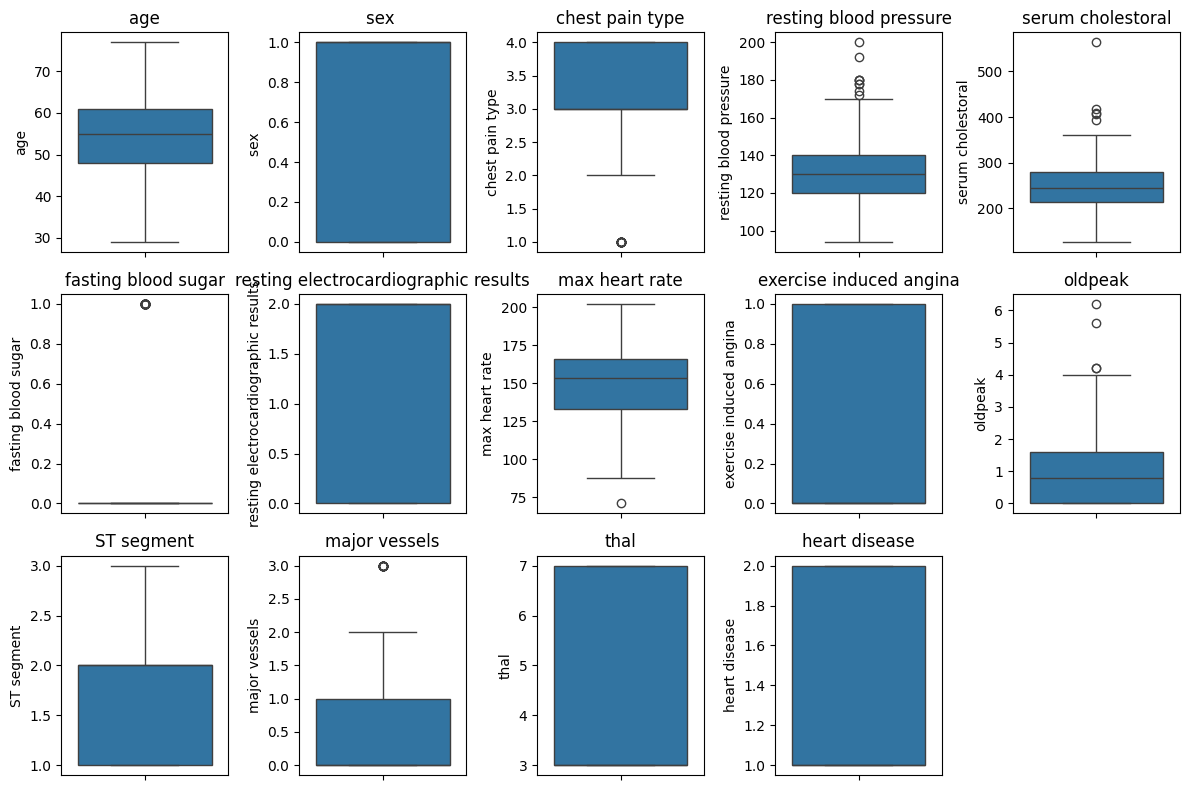

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

 
columns_to_plot = [
i for i in df.columns
] 
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 5, i)   
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
df.isnull().sum()

age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64

<h2 style="text-align:left; color:green;">Exercise 2: Logistic Regression without Grid Search</h2>

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter = 5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

accuracy: 0.9259259259259259

Confusion matrix:
 [[32  1]
 [ 3 18]]

classification report:
               precision    recall  f1-score   support

           1       0.91      0.97      0.94        33
           2       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54



In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter = 1000))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

accuracy: 0.9074074074074074

Confusion matrix:
 [[31  2]
 [ 3 18]]

classification report:
               precision    recall  f1-score   support

           1       0.91      0.94      0.93        33
           2       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



<h2 style="text-align:left; color:green;">Exercise 3: Logistic Regression with Grid Search</h2>

In [22]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],       # force de régularisation
    "penalty": ["l2"],                  # type de pénalisation
    "solver": ["lbfgs", "liblinear"]    # solveurs compatibles
}


model = LogisticRegression(max_iter = 5000)
 

grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
accuracy: 0.9074074074074074

Confusion matrix:
 [[32  1]
 [ 4 17]]

classification report:
               precision    recall  f1-score   support

           1       0.89      0.97      0.93        33
           2       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54



<h2 style="text-align:left; color:green;">Exercise 4 : SVM without Grid Search</h2>

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
 

model = SVC(kernel="rbf", C=1, gamma="scale")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

accuracy: 0.6296296296296297

Confusion matrix:
 [[26  7]
 [13  8]]

classification report:
               precision    recall  f1-score   support

           1       0.67      0.79      0.72        33
           2       0.53      0.38      0.44        21

    accuracy                           0.63        54
   macro avg       0.60      0.58      0.58        54
weighted avg       0.61      0.63      0.61        54



<h2 style="text-align:left; color:green;">Exercise 5 : SVM with Grid Search</h2>

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

param_grid = {
    "C": [0.1, 1, 10, 100],                 # régularisation
    "kernel": ["linear", "rbf", "poly"],    # types de noyaux
    "gamma": ["scale", "auto"]              # paramètre du noyau RBF/poly
}

model = SVC() 

grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

<h2 style="text-align:left; color:green;">Exercise 6 : XGBoost without Grid Search</h2>

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
 

model = XGBClassifier(
    n_estimators=200,       # nombre d’arbres (plus grand = plus précis mais plus lent)
    max_depth=4,            # profondeur max des arbres (évite le sur-apprentissage)
    learning_rate=0.1,      # taux d’apprentissage (équilibre vitesse et précision)
    subsample=0.8,          # fraction d’échantillons utilisés par arbre (réduit overfitting)
    colsample_bytree=0.8,   # fraction de features utilisées par arbre
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"   # métrique adaptée à la classification binaire
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))

<h2 style="text-align:left; color:green;">Exercise 7 : XGBoost with Grid Search</h2>

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

param_grid = {
    "learning_rate": [0.01, 0.1, 0.2],   # taux d’apprentissage
    "n_estimators": [100, 200, 300],     # nombre d’arbres
    "max_depth": [3, 4, 5],              # profondeur max des arbres
    "subsample": [0.8, 1.0],             # fraction d’échantillons par arbre
    "colsample_bytree": [0.8, 1.0]       # fraction de features par arbre
}

model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)


grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", verbose=1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nclassification report:\n", classification_report(y_test, y_pred))